# Watershed Algorithm for Image Segmentation for touching objects in an image

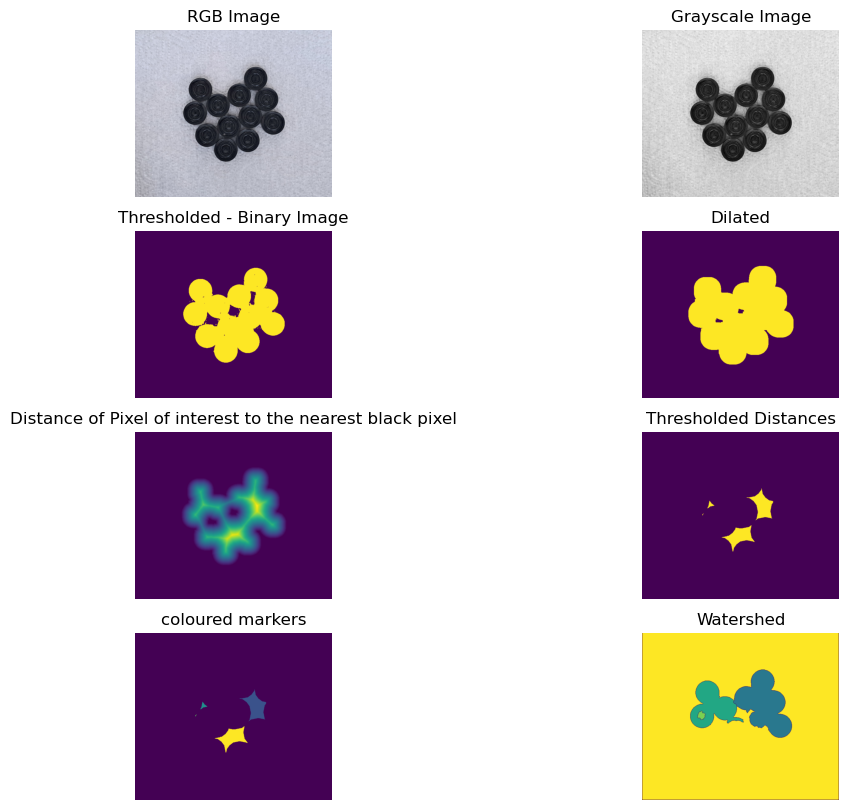

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path = './chess_stones.jpg'

def watershed():
    
    # load and read image
    img = cv.imread(path)
    img = cv.rotate(img, cv.ROTATE_90_COUNTERCLOCKWISE)
    img = cv.resize(img, None, fx = 0.5, fy = 0.5)

    # convert to color and grayscale
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    plt.figure(figsize = (12,10))
    plt.subplot(421)
    plt.imshow(img_rgb), plt.title('RGB Image'), plt.axis('off')
    plt.subplot(422)
    plt.imshow(img_gray, cmap = 'gray'), plt.title('Grayscale Image'), plt.axis('off')
    
    # perform thresholding to receive binary image
    _, binary = cv.threshold(img_gray, 110, 255, cv.THRESH_BINARY_INV)

    plt.subplot(423)
    plt.imshow(binary), plt.title('Thresholded - Binary Image'), plt.axis('off')

    # create kernel and dialate
    kernel = np.ones((13,13), np.uint8)
    dilated = cv.dilate(binary, kernel)

    plt.subplot(424)
    plt.imshow(dilated), plt.title('Dilated'), plt.axis('off')

    # distanceTransform - distance from a current pixel (255) of interest to the nearest black pixel (0)
    distTransform = cv.distanceTransform(dilated, cv.DIST_L2, 5)

    plt.subplot(425)
    plt.imshow(distTransform), plt.title('Distance of Pixel of interest to the nearest black pixel'), plt.axis('off')

    # perform thresholding to the distance Transform
    _, distThresholding = cv.threshold(distTransform, 45, 255, cv.THRESH_BINARY)
    plt.subplot(426)
    plt.imshow(distThresholding), plt.title('Thresholded Distances'), plt.axis('off')
    
    # label the different areas
    distThresholding = np.uint8(distThresholding)
    _, markers = cv.connectedComponents(distThresholding)

    plt.subplot(427)
    plt.imshow(markers), plt.title('coloured markers'), plt.axis('off')

    # plot Watershed
    plt.subplot(428)
    markers = np.int32(markers)
    ws_marks = cv.watershed(img_rgb, markers)
    plt.imshow(ws_marks), plt.title('Watershed'), plt.axis('off')
    
    plt.show()


watershed()

